In [3]:
# import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import os
import glob
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd
import json
import cftime
from itertools import product
from cftime import DatetimeNoLeap
import warnings
%matplotlib inline
from tqdm import tqdm
#from utils import nc_processing
from mpl_axes_aligner import align
from xmip.preprocessing import rename_cmip6
import matplotlib.path as mpath

##### SETTINGS
model = 'UKESM1-0-LL'
scenarios = ['G6sulfur', 'G6solar', 'ssp245', 'ssp585', 'ARISE']
min_year_late_cent, max_year_late_cent = "2050", "2070"
baseline_start, baseline_end = "2014", "2033"

In [4]:
ens_mems = ['r1i1p1f2']

def get_historical_ssp245_ds(variable, table='Amon'):
    """ gets historical and SSP2-4.5 and combine along the time dimension
        returns dataset with 5 members, each running over the historical 
        1850-2014 and ssp245 2015-2100 """
    
    ds_list = []
    for es in ens_mems:
        path = '/badc/cmip6/data/CMIP6/ScenarioMIP/MOHC/UKESM1-0-LL/ssp245/{e}/{t}/{v}/*/latest/'.format(e=es, t=table,v=variable)
        ds = rename_cmip6(xr.open_mfdataset(path+'*.nc'))
        
        path_hist = glob.glob('/badc/cmip6/data/CMIP6/*/*/UKESM1-0-LL/historical/{e}/{t}/{v}/*/latest/'.format(
        t=table, v=variable, e=es))[0]
        ds_hist = rename_cmip6(xr.open_mfdataset(path_hist+'*.nc'))    
        ds = xr.concat([ds_hist, ds], dim='time')
        if 'height' in ds.variables:
            ds = ds.drop_vars('height')
        if 'type' in ds.variables:
            ds = ds.drop_vars('type')
        ds_list.append(ds)
    
    DS = xr.concat(ds_list, dim='Ensemble_member')
    return DS

## for ARISE
def get_ARISE_UKESM(variable='tas', table='Amon'):
    ds_list = []
    paths = glob.glob('/badc/deposited2022/arise/data/ARISE/MOHC/UKESM1-0-LL/arise-sai-1p5/*/{t}/{v}/*/*/'.format(
    t=table, v=variable))
    for path in paths:
        if path.split('/')[9] in ens_mems:
            ds = rename_cmip6(xr.open_mfdataset(path+'*.nc'))
            if 'height' in ds.variables:
                ds = ds.drop_vars('height')
            if 'type' in ds.variables:
                ds = ds.drop_vars('type')
            ds_list.append(ds)
    DS = xr.concat(ds_list, dim='Ensemble_member')
    return DS

def get_time_period(ds, slice_label):
    ds_out = ds.sel(time=assessment_periods[slice_label])
    ds_out.attrs['t_bnds'] = str(assessment_periods[slice_label].start+'_'+assessment_periods[slice_label].stop)
    return ds_out

In [6]:
# take Q as sum of energy leaving air column 
# inputs are time means
# to do - fix the PW version for the case here, where we apply at every latitude

def get_Q(DS, units='W/m2'):
    
    if not units in ['W/m2', 'PW']: #check units
        print('Units must be set to either "W/m2" or "PW", default is W/m2') 
        
    Q = (DS.rsds - DS.rsus + DS.rlds - DS.rlus - DS.hfls - DS.hfss + DS.rsut - DS.rsdt + DS.rlut)
   
    ### need to multiply by area to get these into total AHT units (PW)
    path = '/badc/cmip6/data/CMIP6/CMIP/MOHC/UKESM1-0-LL/piControl/r1i1p1f2/fx/areacella/gn/latest/areacella_fx_UKESM1-0-LL_piControl_r1i1p1f2_gn.nc'
    areacella = rename_cmip6(xr.open_dataset(path))
    area = areacella.sum('x').areacella
    
    unit_conversions = {'W/m2':1,
                        'PW':area/(10**15)} 
    ### now split into moist and dry components. Done following Hahn et al. 2021
    ### https://www.frontiersin.org/articles/10.3389/feart.2021.710036/full
    ### we take moist energy transport as (P-E)*(latent heat of vaporisation).
    ### this neglects the latent heat of fusion for solid precip. 
    ### the dry component is then calculated as the difference between Q and moist

    L = 2.501*(10**6)# latent heat of vaporisation, assumed constant at 2.501 × 10^6 J kg−1
    Qmoist = (DS.pr - DS.evspsbl)*L 

    Q = Q*unit_conversions[units] 
    Qmoist = Qmoist*unit_conversions[units]
        
    Qdry = Q - Qmoist
    return {'Q':Q, 'Qdry':Qdry, 'Qmoist':Qmoist}

In [7]:

rad_flux_vars_surface = ['rsds', 'rsus', 'rlds', 'rlus', 'rsdscs', 'rldscs']
# all radiative vars at surface

rad_flux_vars_TOA = ['rsdt', 'rsut', 'rlut']
# all radiative vars at top-of-atmosphere

heat_flux_vars_surface = ['hfls', 'hfss'] 
# surface upward latent heat flux and surface upward sensible heat flux

PE_vars = ['evspsbl', 'pr']

AHT_vars = ['tas'] + rad_flux_vars_surface + rad_flux_vars_TOA + heat_flux_vars_surface + PE_vars

In [8]:
### SLOW

def get_ahf(scen):
    ds_list_vars = []
    for var in AHT_vars:
        if scen == 'ARISE':
            ds = get_ARISE_UKESM(variable=var, table='Amon')
        if scen == 'ssp245':
            ds = get_historical_ssp245_ds(variable=var, table='Amon')
        #ds = ds.sel(time=slice(min_year_late_cent, max_year_late_cent)).mean('time')
        ds = ds.mean('x')
        ds_list_vars.append(ds)
    DS = xr.merge(ds_list_vars, compat='override')
    Q = get_Q(DS, units='PW')
    return Q
    

Q_arise =  get_ahf('ARISE')['Q'].isel(Ensemble_member=0).load()
Q_ssp245 = get_ahf('ssp245')['Q'].isel(Ensemble_member=0).load()

In [9]:
Q_arise

<xarray.DataArray (time: 432, y: 144)> Size: 498kB
array([[0.0022945 , 0.00694758, 0.01210505, ..., 0.04071764, 0.02428154,
        0.00812159],
       [0.00422553, 0.01274381, 0.02237909, ..., 0.0427886 , 0.02549827,
        0.0084407 ],
       [0.00738344, 0.02199888, 0.03736425, ..., 0.04114902, 0.02485209,
        0.00824601],
       ...,
       [0.00467453, 0.01388172, 0.02441151, ..., 0.03957757, 0.02349575,
        0.00772834],
       [0.00261526, 0.00766   , 0.01339896, ..., 0.03702588, 0.02264105,
        0.00785247],
       [0.00199155, 0.00595182, 0.01027463, ..., 0.04253526, 0.02576591,
        0.00871522]])
Coordinates:
  * time     (time) object 3kB 2035-01-16 00:00:00 ... 2070-12-16 00:00:00
  * y        (y) float64 1kB -89.38 -88.12 -86.88 -85.62 ... 86.88 88.12 89.38

In [12]:
## add ocean heat flux

def get_ohf(scen, basin=1):
    if scen == 'ARISE':
        ds = get_ARISE_UKESM(variable='hfbasin', table='Omon')
    if scen == 'ssp245':
        ds = get_historical_ssp245_ds(variable='hfbasin', table='Omon')
    NHT_ocean = ds.sel(basin=basin) #1 for global ocean
    print('Selected ocean basin: ', NHT_ocean.sector.values) #check we have the right basin
    #NHT_ocean = NHT_ocean.sel(time=slice(min_year_late_cent, max_year_late_cent)).mean('time')
    return NHT_ocean

NHT_ocean_arise = get_ohf(scen='ARISE').isel(Ensemble_member=0).load()
NHT_ocean_ssp245 = get_ohf(scen='ssp245').isel(Ensemble_member=0).load()

# regrid onto y coords of the atmos:
NHT_ocean_arise = NHT_ocean_arise.interp(y=Q_arise.y, method='linear')
NHT_ocean_ssp245 = NHT_ocean_ssp245.interp(y=Q_arise.y, method='linear')

Selected ocean basin:  b'global_ocean'
Selected ocean basin:  b'global_ocean'


In [13]:
get_ohf(scen='ARISE', basin=0)

Selected ocean basin:  b'atlantic_arctic_ocean'


<xarray.Dataset> Size: 3MB
Dimensions:      (time: 432, Ensemble_member: 1, bnds: 2, y: 330)
Coordinates:
  * time         (time) object 3kB 2035-01-16 00:00:00 ... 2070-12-16 00:00:00
  * y            (y) float64 3kB -85.35 -85.19 -85.04 ... 81.73 81.77 81.79
    sector       |S21 21B dask.array<chunksize=(), meta=np.ndarray>
Dimensions without coordinates: Ensemble_member, bnds
Data variables:
    time_bounds  (Ensemble_member, time, bnds) object 7kB dask.array<chunksize=(1, 1, 2), meta=np.ndarray>
    lat_bounds   (Ensemble_member, time, y, bnds) float64 2MB dask.array<chunksize=(1, 180, 330, 2), meta=np.ndarray>
    hfbasin      (Ensemble_member, time, y) float32 570kB dask.array<chunksize=(1, 1, 330), meta=np.ndarray>
Attributes: (12/48)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            ARISE
    branch_method:          standard
    branch_time_in_child:   66600.0
    branch_time_in_parent:  66600.0
    creation_date:          2022-04-12T16:29:37Z
    ...                     ...
    cmor_version:           3.6.1
    grid_label:             gnz
    history:                Thu May  5 21:49:57 2022: ncatted -a grid_label,g...
    nominal_resolution:     100 km
    grid_description:       Native eORCA1 tripolar primarily 1 deg with merid...
    NCO:                    netCDF Operators version 5.0.1 (Homepage = http:/...

In [8]:

# d(NHT)/d(y) = Q
# so NHT is integral of Q from south pole to lat


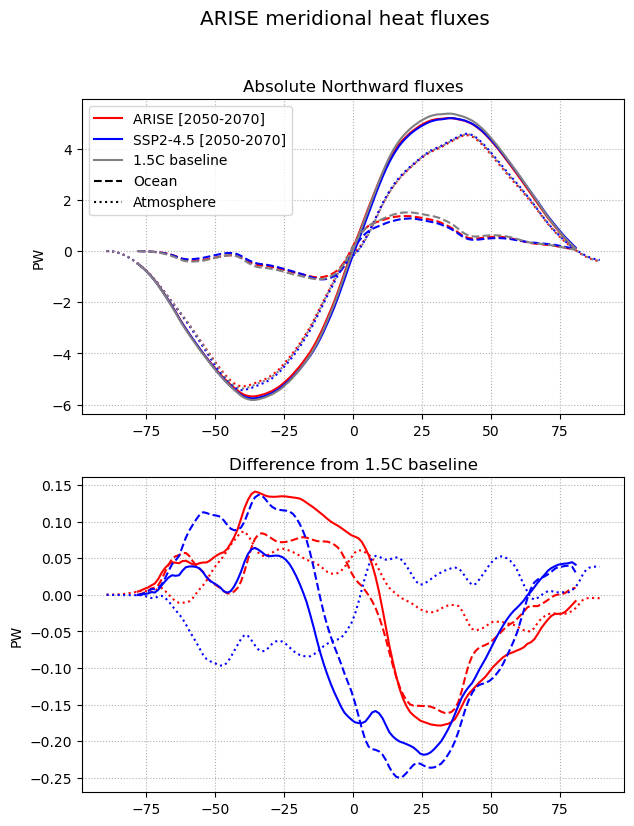

In [9]:
### now plot:

fig, axs = plt.subplots(2, 1, figsize=(7,9))

ax = axs[0]
#### ARISE 
# atmos
Q = Q_arise.sel(time=slice(min_year_late_cent, max_year_late_cent)).mean('time')
NHT_atmos = []
for j in range(len(Q.y.values)):
    NHT_atmos.append(-np.sum(Q.values[0:j]))
    j=j+1
ax.plot(Q.y.values, NHT_atmos, ls='dotted', c='red')
# ocean
O = NHT_ocean_arise.sel(time=slice(min_year_late_cent, max_year_late_cent)).mean('time')
ax.plot(O.y.values, O.hfbasin.values/(10**15), ls='--', c='red')
# total
ax.plot(O.y.values, NHT_atmos + O.hfbasin.values/(10**15), label='ARISE [2050-2070]', c='red')


### SSP245 
# atmos
Q = Q_ssp245.sel(time=slice(min_year_late_cent, max_year_late_cent)).mean('time')
NHT_atmos = []
for j in range(len(Q.y.values)):
    NHT_atmos.append(-np.sum(Q.values[0:j]))
    j=j+1
ax.plot(Q.y.values, NHT_atmos, ls='dotted', c='blue')
# ocean
O = NHT_ocean_ssp245.sel(time=slice(min_year_late_cent, max_year_late_cent)).mean('time')
ax.plot(O.y.values, O.hfbasin.values/(10**15), ls='--', c='blue')
# total
ax.plot(O.y.values, NHT_atmos + O.hfbasin.values/(10**15), label='SSP2-4.5 [2050-2070]', c='blue')


### baseline
# atmos
Q_baseline = Q_ssp245.sel(time=slice(baseline_start, baseline_end)).mean('time')
NHT_atmos_baseline = []
for j in range(len(Q_baseline.y.values)):
    NHT_atmos_baseline.append(-np.sum(Q_baseline.values[0:j]))
    j=j+1
ax.plot(Q_baseline.y.values, NHT_atmos_baseline, ls='dotted', c='gray')

# ocean
O_baseline = NHT_ocean_ssp245.sel(time=slice(baseline_start, baseline_end)).mean('time')
ax.plot(O_baseline.y.values, O_baseline.hfbasin.values/(10**15), ls='--', c='gray')

# total
ax.plot(O_baseline.y.values, NHT_atmos_baseline + O_baseline.hfbasin.values/(10**15), label='1.5C baseline', c='gray')

ax.plot([], [], ls='--', c='black', label='Ocean')
ax.plot([], [], ls='dotted', c='black', label='Atmosphere')

ax.legend()
ax.grid(ls='dotted')
ax.set_ylabel('PW')
ax.set_title('Absolute Northward fluxes')



##### now repeat showing just the differences:
ax = axs[1]
#### ARISE 
# atmos
Q = Q_arise.sel(time=slice(min_year_late_cent, max_year_late_cent)).mean('time')
NHT_atmos = []
for j in range(len(Q.y.values)):
    NHT_atmos.append(-np.sum(Q.values[0:j]))
    j=j+1
ax.plot(Q.y.values, np.array(NHT_atmos) - np.array(NHT_atmos_baseline), ls='dotted', c='red')
# ocean
O = NHT_ocean_arise.sel(time=slice(min_year_late_cent, max_year_late_cent)).mean('time')
ax.plot(O.y.values, O.hfbasin.values/(10**15) - O_baseline.hfbasin.values/(10**15), ls='--', c='red')
# total
ax.plot(O.y.values, np.array(NHT_atmos) - np.array(NHT_atmos_baseline) + O.hfbasin.values/(10**15) - O_baseline.hfbasin.values/(10**15),
        label='ARISE', c='red')


### SSP245 
# atmos
Q = Q_ssp245.sel(time=slice(min_year_late_cent, max_year_late_cent)).mean('time')
NHT_atmos = []
for j in range(len(Q.y.values)):
    NHT_atmos.append(-np.sum(Q.values[0:j]))
    j=j+1
ax.plot(Q.y.values, np.array(NHT_atmos) - np.array(NHT_atmos_baseline), ls='dotted', c='blue')
# ocean
O = NHT_ocean_ssp245.sel(time=slice(min_year_late_cent, max_year_late_cent)).mean('time')
ax.plot(O.y.values, O.hfbasin.values/(10**15) - O_baseline.hfbasin.values/(10**15), ls='--', c='blue')
# total
ax.plot(O.y.values, np.array(NHT_atmos) - np.array(NHT_atmos_baseline) + O.hfbasin.values/(10**15) - O_baseline.hfbasin.values/(10**15), 
        label='SSP2-4.5', c='blue')

#ax.legend()
ax.grid(ls='dotted')
ax.set_ylabel('PW')
ax.set_title('Difference from 1.5C baseline')

plt.suptitle('ARISE meridional heat fluxes', fontsize='x-large')

plt.savefig('Figures/Meridional_heat_fluxes_ARISE')

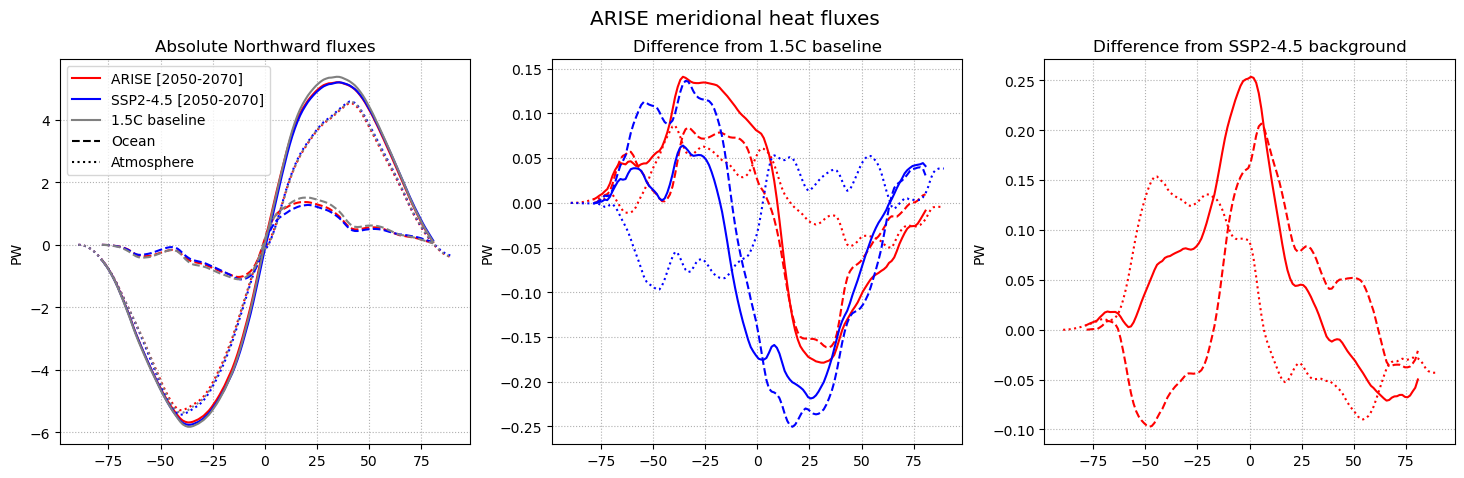

In [10]:
### now plot:

fig, axs = plt.subplots(1, 3, figsize=(18,5))

ax = axs[0]
#### ARISE 
# atmos
Q = Q_arise.sel(time=slice(min_year_late_cent, max_year_late_cent)).mean('time')
NHT_atmos = []
for j in range(len(Q.y.values)):
    NHT_atmos.append(-np.sum(Q.values[0:j]))
    j=j+1
ax.plot(Q.y.values, NHT_atmos, ls='dotted', c='red')
# ocean
O = NHT_ocean_arise.sel(time=slice(min_year_late_cent, max_year_late_cent)).mean('time')
ax.plot(O.y.values, O.hfbasin.values/(10**15), ls='--', c='red')
# total
ax.plot(O.y.values, NHT_atmos + O.hfbasin.values/(10**15), label='ARISE [2050-2070]', c='red')


### SSP245 
# atmos
Q = Q_ssp245.sel(time=slice(min_year_late_cent, max_year_late_cent)).mean('time')
NHT_atmos = []
for j in range(len(Q.y.values)):
    NHT_atmos.append(-np.sum(Q.values[0:j]))
    j=j+1
ax.plot(Q.y.values, NHT_atmos, ls='dotted', c='blue')
# ocean
O = NHT_ocean_ssp245.sel(time=slice(min_year_late_cent, max_year_late_cent)).mean('time')
ax.plot(O.y.values, O.hfbasin.values/(10**15), ls='--', c='blue')
# total
ax.plot(O.y.values, NHT_atmos + O.hfbasin.values/(10**15), label='SSP2-4.5 [2050-2070]', c='blue')


### baseline
# atmos
Q_baseline = Q_ssp245.sel(time=slice(baseline_start, baseline_end)).mean('time')
NHT_atmos_baseline = []
for j in range(len(Q_baseline.y.values)):
    NHT_atmos_baseline.append(-np.sum(Q_baseline.values[0:j]))
    j=j+1
ax.plot(Q_baseline.y.values, NHT_atmos_baseline, ls='dotted', c='gray')

# ocean
O_baseline = NHT_ocean_ssp245.sel(time=slice(baseline_start, baseline_end)).mean('time')
ax.plot(O_baseline.y.values, O_baseline.hfbasin.values/(10**15), ls='--', c='gray')

# total
ax.plot(O_baseline.y.values, NHT_atmos_baseline + O_baseline.hfbasin.values/(10**15), label='1.5C baseline', c='gray')

ax.plot([], [], ls='--', c='black', label='Ocean')
ax.plot([], [], ls='dotted', c='black', label='Atmosphere')

ax.legend()
ax.grid(ls='dotted')
ax.set_ylabel('PW')
ax.set_title('Absolute Northward fluxes')



##### now repeat showing just the differences:
ax = axs[1]
#### ARISE 
# atmos
Q = Q_arise.sel(time=slice(min_year_late_cent, max_year_late_cent)).mean('time')
NHT_atmos = []
for j in range(len(Q.y.values)):
    NHT_atmos.append(-np.sum(Q.values[0:j]))
    j=j+1
ax.plot(Q.y.values, np.array(NHT_atmos) - np.array(NHT_atmos_baseline), ls='dotted', c='red')
# ocean
O = NHT_ocean_arise.sel(time=slice(min_year_late_cent, max_year_late_cent)).mean('time')
ax.plot(O.y.values, O.hfbasin.values/(10**15) - O_baseline.hfbasin.values/(10**15), ls='--', c='red')
# total
ax.plot(O.y.values, np.array(NHT_atmos) - np.array(NHT_atmos_baseline) + O.hfbasin.values/(10**15) - O_baseline.hfbasin.values/(10**15),
        label='ARISE', c='red')


### SSP245 
# atmos
Q = Q_ssp245.sel(time=slice(min_year_late_cent, max_year_late_cent)).mean('time')
NHT_atmos = []
for j in range(len(Q.y.values)):
    NHT_atmos.append(-np.sum(Q.values[0:j]))
    j=j+1
ax.plot(Q.y.values, np.array(NHT_atmos) - np.array(NHT_atmos_baseline), ls='dotted', c='blue')
# ocean
O = NHT_ocean_ssp245.sel(time=slice(min_year_late_cent, max_year_late_cent)).mean('time')
ax.plot(O.y.values, O.hfbasin.values/(10**15) - O_baseline.hfbasin.values/(10**15), ls='--', c='blue')
# total
ax.plot(O.y.values, np.array(NHT_atmos) - np.array(NHT_atmos_baseline) + O.hfbasin.values/(10**15) - O_baseline.hfbasin.values/(10**15), 
        label='SSP2-4.5', c='blue')

#ax.legend()
ax.grid(ls='dotted')
ax.set_ylabel('PW')
ax.set_title('Difference from 1.5C baseline')




##### now repeat showing just the difference betweeen arise and ssp245:
ax = axs[2] 
# atmos
Q_arise_plot = Q_arise.sel(time=slice(min_year_late_cent, max_year_late_cent)).mean('time')
NHT_atmos_arise = []
for j in range(len(Q_arise_plot.y.values)):
    NHT_atmos_arise.append(-np.sum(Q_arise_plot.values[0:j]))
    j=j+1
Q_ssp245_plot = Q_ssp245.sel(time=slice(min_year_late_cent, max_year_late_cent)).mean('time')
NHT_atmos_ssp245 = []
for j in range(len(Q_ssp245_plot.y.values)):
    NHT_atmos_ssp245.append(-np.sum(Q_ssp245_plot.values[0:j]))
    j=j+1
ax.plot(Q_arise_plot.y.values, np.array(NHT_atmos_arise) - np.array(NHT_atmos_ssp245), ls='dotted', c='red')
# ocean
O_arise_plot = NHT_ocean_arise.sel(time=slice(min_year_late_cent, max_year_late_cent)).mean('time')
O_ssp245_plot = NHT_ocean_ssp245.sel(time=slice(min_year_late_cent, max_year_late_cent)).mean('time')
ax.plot(O_arise_plot.y.values, O_arise_plot.hfbasin.values/(10**15) - O_ssp245_plot.hfbasin.values/(10**15), ls='--', c='red')
# total
ax.plot(O_ssp245_plot.y.values, np.array(NHT_atmos_arise) - np.array(NHT_atmos_ssp245) + O_arise_plot.hfbasin.values/(10**15) - O_ssp245_plot.hfbasin.values/(10**15),
        label='ARISE', c='red')

#ax.legend()
ax.grid(ls='dotted')
ax.set_ylabel('PW')
ax.set_title('Difference from SSP2-4.5 background')

plt.suptitle('ARISE meridional heat fluxes', fontsize='x-large')

plt.savefig('Figures/Meridional_heat_fluxes_ARISE_v2')